In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
import statsmodels.api as sm
import io
import requests
import zipfile
import sys
sys.path.append("../utils")
from indicators import compute_rsi

print("All imports successful")

All imports successful


In [4]:
# Download Fama-French 3-factor daily data directly
url = "https://mba.tuck.dartmouth.edu/pages/faculty/ken.french/ftp/F-F_Research_Data_Factors_daily_CSV.zip"

response = requests.get(url)
zf = zipfile.ZipFile(io.BytesIO(response.content))

# Check what's inside
print("Files in zip:", zf.namelist())

# Find the CSV file
csv_name = zf.namelist()[0]
with zf.open(csv_name) as f:
    raw = f.read().decode('utf-8')

# Parse — skip header lines until we hit the data
lines = raw.split('\n')
start_line = 0
for i, line in enumerate(lines):
    stripped = line.strip()
    if stripped and (stripped[:4].isdigit()):
        start_line = i
        break

ff3 = pd.read_csv(
    io.StringIO('\n'.join(lines[start_line:])),
    header=None,
    names=['Date', 'Mkt-RF', 'SMB', 'HML', 'RF'],
    on_bad_lines='skip'
)

# Clean and format
ff3 = ff3.dropna()
ff3 = ff3[ff3['Date'].astype(str).str.len() == 8]
ff3['Date'] = pd.to_datetime(ff3['Date'], format='%Y%m%d')
ff3 = ff3.set_index('Date')
ff3 = ff3.apply(pd.to_numeric, errors='coerce').dropna()
ff3 = ff3 / 100

# Filter to our period
ff3 = ff3['2010-01-01':'2024-01-01']

print(f"\nFF3 data loaded: {len(ff3)} observations")
print(f"Date range: {ff3.index[0].date()} to {ff3.index[-1].date()}")
print(ff3.head())

Files in zip: ['F-F_Research_Data_Factors_daily.csv']

FF3 data loaded: 3522 observations
Date range: 2010-01-04 to 2023-12-29
            Mkt-RF     SMB     HML   RF
Date                                   
2010-01-04  0.0169  0.0061  0.0114  0.0
2010-01-05  0.0031 -0.0064  0.0122  0.0
2010-01-06  0.0013 -0.0023  0.0055  0.0
2010-01-07  0.0040  0.0009  0.0096  0.0
2010-01-08  0.0033  0.0036  0.0002  0.0


In [5]:
# Load SPY and build strategy returns
df = yf.download("SPY", start="2010-01-01",
                  end="2024-01-01", auto_adjust=True)
df.columns = df.columns.get_level_values(0)
price = df["Close"].squeeze()
log_returns = np.log(price / price.shift(1)).dropna()

# SMA 50/200 strategy
sma50  = price.rolling(50).mean()
sma200 = price.rolling(200).mean()
sma_pos = (sma50 > sma200).astype(int).shift(1).fillna(0)
sma_pos = sma_pos.reindex(log_returns.index).fillna(0)
sma_ret = sma_pos * log_returns - sma_pos.diff().abs().fillna(0) * 0.0006

# RSI(2) strategy
rsi2 = compute_rsi(price, period=2)
pos_list, cp = [], 0
for i in range(len(rsi2)):
    in_uptrend = price.iloc[i] > sma200.iloc[i]
    if cp == 0 and rsi2.iloc[i] < 10 and in_uptrend:
        cp = 1
    elif cp == 1 and (rsi2.iloc[i] > 90 or not in_uptrend):
        cp = 0
    pos_list.append(cp)
rsi2_pos = pd.Series(pos_list, index=price.index).shift(1).fillna(0)
rsi2_ret = rsi2_pos.reindex(log_returns.index).fillna(0) * log_returns
rsi2_ret = rsi2_ret - rsi2_pos.diff().abs().fillna(0) * 0.0006

print(f"SMA returns  : {len(sma_ret)} observations")
print(f"RSI2 returns : {len(rsi2_ret)} observations")
print(f"FF3 factors  : {len(ff3)} observations")

[*********************100%***********************]  1 of 1 completed

SMA returns  : 3521 observations
RSI2 returns : 3522 observations
FF3 factors  : 3522 observations


In [6]:
def factor_regression(strategy_returns, ff3, name):
    """
    Run Fama-French 3-factor regression on strategy returns.
    Returns alpha, betas, R-squared, t-statistics.
    """
    # Align all series
    aligned = pd.concat([strategy_returns, ff3], axis=1).dropna()
    aligned.columns = ['ret', 'Mkt-RF', 'SMB', 'HML', 'RF']

    # Excess strategy return over risk-free rate
    y = aligned['ret'] - aligned['RF']

    # Factor matrix
    X = aligned[['Mkt-RF', 'SMB', 'HML']]
    X = sm.add_constant(X)

    # OLS regression
    model = sm.OLS(y, X).fit()

    alpha_daily = model.params['const']
    alpha_ann   = alpha_daily * 252

    print(f"\n{'='*55}")
    print(f"  FACTOR ATTRIBUTION — {name}")
    print(f"{'='*55}")
    print(f"  Alpha (daily)    : {alpha_daily:.6f}")
    print(f"  Alpha (annual)   : {alpha_ann:.2%}")
    print(f"  Alpha t-stat     : {model.tvalues['const']:.2f}")
    print(f"  Alpha p-value    : {model.pvalues['const']:.4f}")
    print(f"  Mkt-RF beta      : {model.params['Mkt-RF']:.3f} (t={model.tvalues['Mkt-RF']:.2f})")
    print(f"  SMB beta         : {model.params['SMB']:.3f} (t={model.tvalues['SMB']:.2f})")
    print(f"  HML beta         : {model.params['HML']:.3f} (t={model.tvalues['HML']:.2f})")
    print(f"  R-squared        : {model.rsquared:.3f}")
    print(f"{'='*55}")
    print(f"  Significant alpha? {'YES' if abs(model.tvalues['const']) > 2 else 'NO'} (need |t| > 2)")

    return model

# Run on both strategies
sma_model  = factor_regression(sma_ret,  ff3, "SMA 50/200")
rsi2_model = factor_regression(rsi2_ret, ff3, "RSI(2) + Filter")


  FACTOR ATTRIBUTION — SMA 50/200
  Alpha (daily)    : -0.000036
  Alpha (annual)   : -0.90%
  Alpha t-stat     : -0.40
  Alpha p-value    : 0.6887
  Mkt-RF beta      : 0.629 (t=77.14)
  SMB beta         : -0.165 (t=-10.78)
  HML beta         : -0.000 (t=-0.03)
  R-squared        : 0.633
  Significant alpha? NO (need |t| > 2)

  FACTOR ATTRIBUTION — RSI(2) + Filter
  Alpha (daily)    : 0.000028
  Alpha (annual)   : 0.70%
  Alpha t-stat     : 0.37
  Alpha p-value    : 0.7120
  Mkt-RF beta      : 0.205 (t=29.80)
  SMB beta         : -0.052 (t=-4.04)
  HML beta         : -0.023 (t=-2.40)
  R-squared        : 0.205
  Significant alpha? NO (need |t| > 2)


C:\Users\User\AppData\Local\Temp\ipykernel_20856\3646252117.py:7: Pandas4Warning: Sorting by default when concatenating all DatetimeIndex is deprecated.  In the future, pandas will respect the default of `sort=False`. Specify `sort=True` or `sort=False` to silence this message. If you see this warnings when not directly calling concat, report a bug to pandas.
  aligned = pd.concat([strategy_returns, ff3], axis=1).dropna()


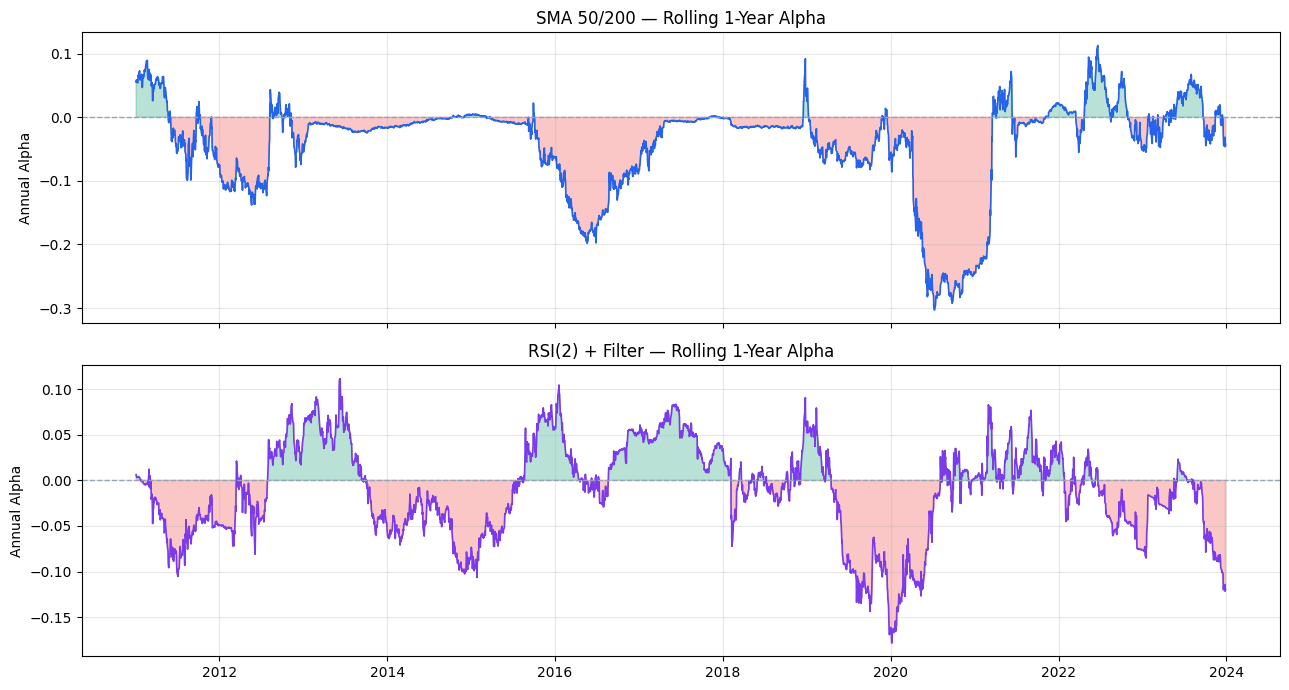


SMA  — % of time with positive alpha: 21.9%
RSI2 — % of time with positive alpha: 43.9%


In [7]:
def rolling_alpha(strategy_returns, ff3, name, window=252):
    """
    Calculate rolling 1-year alpha to see
    if the edge is consistent over time.
    """
    aligned = pd.concat([strategy_returns, ff3],
                        axis=1, sort=True).dropna()
    aligned.columns = ['ret', 'Mkt-RF', 'SMB', 'HML', 'RF']

    y = aligned['ret'] - aligned['RF']
    X = sm.add_constant(aligned[['Mkt-RF', 'SMB', 'HML']])

    alphas = []
    dates  = []

    for i in range(window, len(y)):
        y_w = y.iloc[i-window:i]
        X_w = X.iloc[i-window:i]
        try:
            m = sm.OLS(y_w, X_w).fit()
            alphas.append(m.params['const'] * 252)
            dates.append(y.index[i])
        except:
            continue

    alpha_series = pd.Series(alphas, index=dates)
    return alpha_series

# Calculate rolling alpha for both strategies
sma_alpha  = rolling_alpha(sma_ret,  ff3, "SMA 50/200")
rsi2_alpha = rolling_alpha(rsi2_ret, ff3, "RSI(2)")

# Plot
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(13, 7), sharex=True)

ax1.plot(sma_alpha, color='#2563eb', lw=1.2)
ax1.axhline(0, color='#94a3b8', lw=1, linestyle='--')
ax1.fill_between(sma_alpha.index, sma_alpha, 0,
                 where=(sma_alpha > 0),
                 alpha=0.3, color='#1D9E75')
ax1.fill_between(sma_alpha.index, sma_alpha, 0,
                 where=(sma_alpha < 0),
                 alpha=0.3, color='#ef4444')
ax1.set_title('SMA 50/200 — Rolling 1-Year Alpha')
ax1.set_ylabel('Annual Alpha')
ax1.grid(True, alpha=0.3)

ax2.plot(rsi2_alpha, color='#7c3aed', lw=1.2)
ax2.axhline(0, color='#94a3b8', lw=1, linestyle='--')
ax2.fill_between(rsi2_alpha.index, rsi2_alpha, 0,
                 where=(rsi2_alpha > 0),
                 alpha=0.3, color='#1D9E75')
ax2.fill_between(rsi2_alpha.index, rsi2_alpha, 0,
                 where=(rsi2_alpha < 0),
                 alpha=0.3, color='#ef4444')
ax2.set_title('RSI(2) + Filter — Rolling 1-Year Alpha')
ax2.set_ylabel('Annual Alpha')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nSMA  — % of time with positive alpha: {(sma_alpha>0).mean():.1%}")
print(f"RSI2 — % of time with positive alpha: {(rsi2_alpha>0).mean():.1%}")